In [28]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import time
import torchinfo
import numpy as np
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(device)

mps


In [3]:
diff_model_accu = {}
diff_model_traning = {}
diff_model_loss = {}
diff_model_weights = {}

In [4]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.ImageFolder(root="/Users/pulasthyareddy/Downloads/datasets/cnn_dataset", transform=transform) 
# dataset = datasets.ImageFolder(root="/Users/pulasthyareddy/Downloads/datasets/temp", transform=transform) 

class_to_idx = dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

In [27]:
total_samples = len(dataset)
print(f"Total number of samples: {total_samples:,}")

if isinstance(dataset[0], tuple):
    sample_image, sample_label = dataset[0]
else:
    sample_image = dataset[0]

if isinstance(sample_image, torch.Tensor):
    sample_image = sample_image.numpy()

print(f"Image dimensions: {sample_image.shape}")
print(f"Data type: {sample_image.dtype}")

Total number of samples: 100,800
Image dimensions: (1, 28, 28)
Data type: float32


In [36]:
total_samples = len(dataset)
image_dimensions = (28, 28)
data_type = "torch.float32"
num_classes = 36

samples_per_class = total_samples // num_classes

report = f"""
Dataset Summary Report
=====================

Basic Information:
-----------------
- Total number of images: {total_samples:,}
- Image dimensions: {image_dimensions[0]}x{image_dimensions[1]} pixels
- Data type: {data_type}
- Color format: Grayscale (single channel)

Class Information:
----------------
- Number of classes: {num_classes}
- Images per class: ~{samples_per_class:,}
- Classes: Letters and potentially numbers
- Class distribution: Balanced (approximately {samples_per_class} images per class)

Image Characteristics:
--------------------
- Format: Black background with white characters
- Resolution: {image_dimensions[0]}x{image_dimensions[1]} pixels per image
- Preprocessing: Standardized size and format across all images
- Features: Handwritten characters with varying styles and orientations

Dataset Properties:
-----------------
- Total dataset size: 100,800 samples
- Balanced class distribution
- Standardized preprocessing applied
- Suitable for character recognition tasks

Data Format:
-----------
- Input shape: torch.Size([1, 28, 28])
- Pixel value range: Normalized values
- Storage format: PyTorch tensors
"""

print(report)


Dataset Summary Report

Basic Information:
-----------------
- Total number of images: 100,800
- Image dimensions: 28x28 pixels
- Data type: torch.float32
- Color format: Grayscale (single channel)

Class Information:
----------------
- Number of classes: 36
- Images per class: ~2,800
- Classes: Letters and potentially numbers
- Class distribution: Balanced (approximately 2800 images per class)

Image Characteristics:
--------------------
- Format: Black background with white characters
- Resolution: 28x28 pixels per image
- Preprocessing: Standardized size and format across all images
- Features: Handwritten characters with varying styles and orientations

Dataset Properties:
-----------------
- Total dataset size: 100,800 samples
- Balanced class distribution
- Standardized preprocessing applied
- Suitable for character recognition tasks

Data Format:
-----------
- Input shape: torch.Size([1, 28, 28])
- Pixel value range: Normalized values
- Storage format: PyTorch tensors



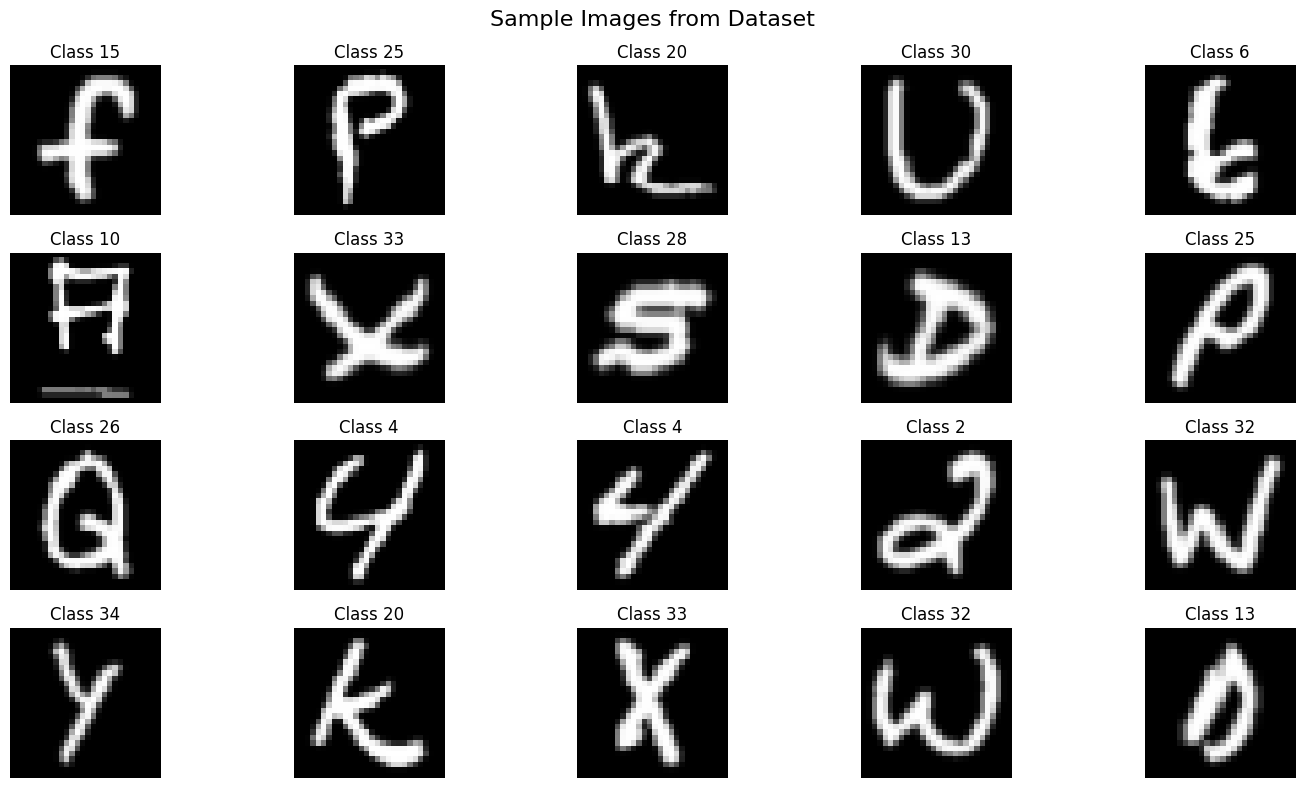


Dataset Information:
Number of Images: 100800
Image Dimensions: torch.Size([1, 28, 28])
Data Type: torch.float32


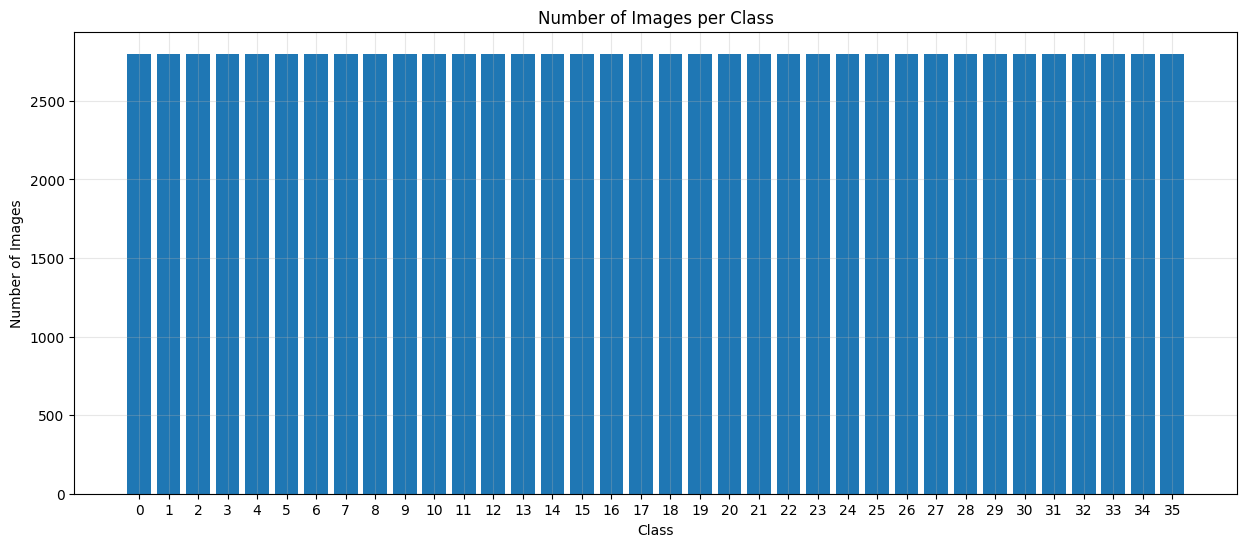

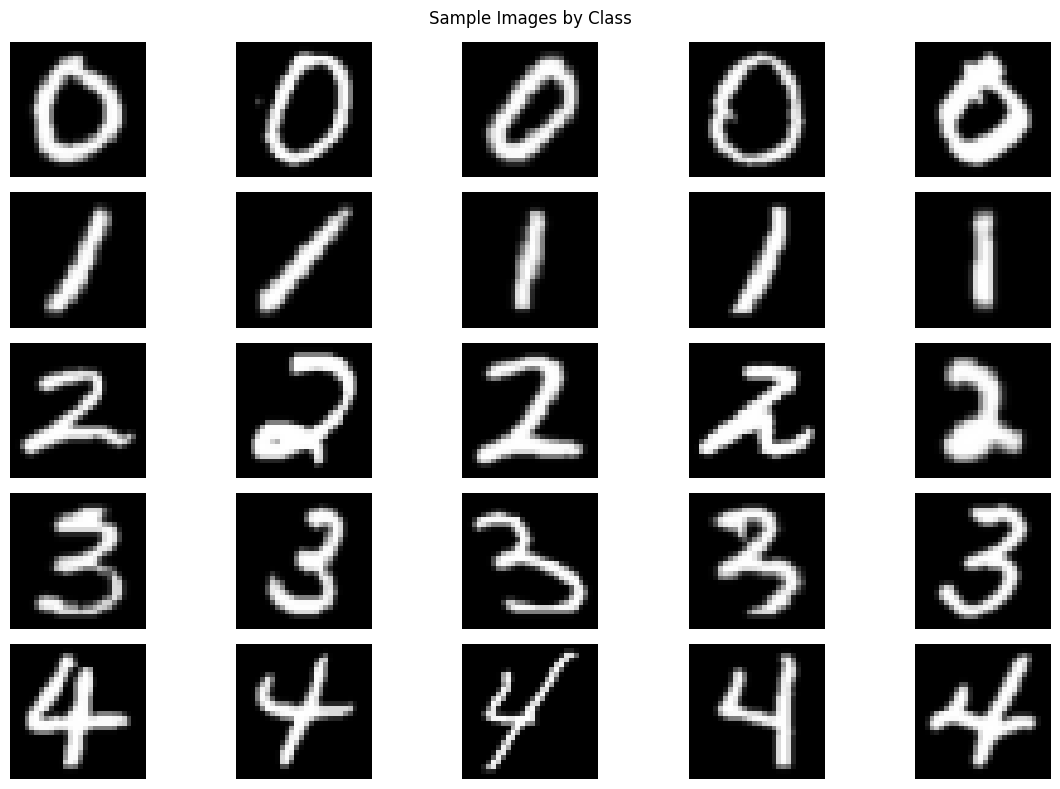

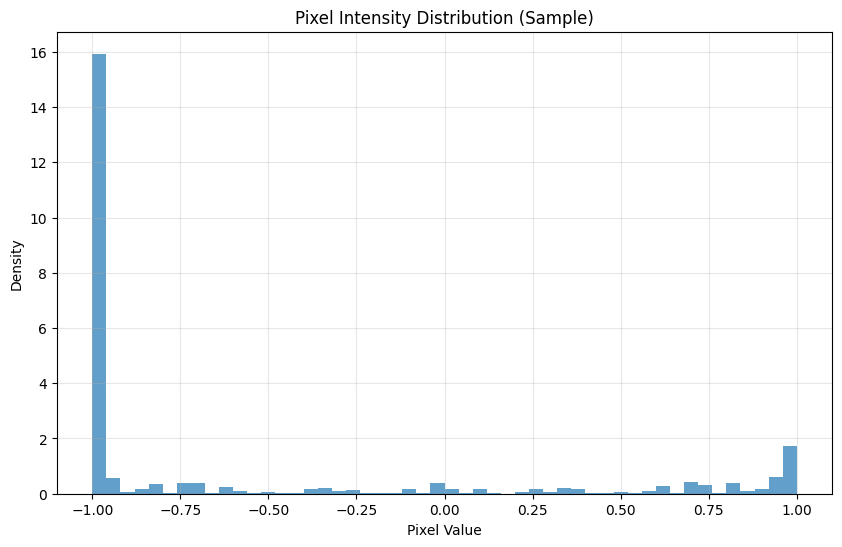

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def visualize_dataset(dataset):
    plt.figure(figsize=(15, 8))
    plt.suptitle('Sample Images from Dataset', fontsize=16)
    
    for i in range(20):
        plt.subplot(4, 5, i + 1)
        idx = np.random.randint(len(dataset))
        img, label = dataset[idx]
        
        img = img.numpy()
        
        if img.shape[0] == 1:
            plt.imshow(img.squeeze(), cmap='gray')
        else:
            plt.imshow(np.transpose(img, (1, 2, 0)))
            
        plt.title(f'Class {label}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

    print("\nDataset Information:")
    print("Number of Images:", len(dataset))
    sample_img, _ = dataset[0]
    print("Image Dimensions:", sample_img.shape)
    print("Data Type:", sample_img.dtype)
    
    labels = [label for _, label in dataset]
    unique_labels, counts = np.unique(labels, return_counts=True)
    
    plt.figure(figsize=(15, 6))
    plt.bar(unique_labels, counts)
    plt.title('Number of Images per Class')
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.xticks(unique_labels)
    plt.grid(True, alpha=0.3)
    plt.show()

    num_classes = len(unique_labels)
    samples_per_class = 5
    class_samples = {i: [] for i in range(num_classes)}
    
    for idx in range(len(dataset)):
        img, label = dataset[idx]
        if len(class_samples[label]) < samples_per_class:
            class_samples[label].append(img)
        if all(len(samples) >= samples_per_class for samples in class_samples.values()):
            break
    
    plt.figure(figsize=(12, 8))
    for i in range(5):
        for j in range(samples_per_class):
            plt.subplot(5, samples_per_class, i*samples_per_class + j + 1)
            img = class_samples[i][j].numpy()
            if img.shape[0] == 1:
                plt.imshow(img.squeeze(), cmap='gray')
            else:
                plt.imshow(np.transpose(img, (1, 2, 0)))
            plt.axis('off')
            if j == 0:
                plt.ylabel(f'Class {i}')
    
    plt.suptitle('Sample Images by Class')
    plt.tight_layout()
    plt.show()

    sample_images = []
    for i in range(min(1000, len(dataset))):
        img, _ = dataset[i]
        sample_images.append(img.numpy().flatten())
    
    sample_pixels = np.concatenate(sample_images)
    plt.figure(figsize=(10, 6))
    plt.hist(sample_pixels, bins=50, density=True, alpha=0.7)
    plt.title('Pixel Intensity Distribution (Sample)')
    plt.xlabel('Pixel Value')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.3)
    plt.show()

visualize_dataset(dataset)

# Creating Data split into train, validate and test

In [7]:
train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)
train_data, validate_data = train_test_split(train_data, test_size=0.2, random_state=42)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
validate_loader = DataLoader(validate_data, batch_size=64, shuffle=True)
# test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from sklearn.model_selection import train_test_split

class BaseCNN(nn.Module):
    def __init__(self, dropout_perc):
        super(BaseCNN, self).__init__()
        # CNN layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1) 
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1) 
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.conv5 = nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1)

        self.fc1 = nn.Linear(128 * 1 * 1, 256)
        # self.fc1 = nn.Linear(256 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 36)

        # Pooling layers
        self.max_pool_2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.max_pool_1 = nn.MaxPool2d(kernel_size=2, stride=1, padding=0)
        self.avg_pool_2 = nn.AvgPool2d(kernel_size=2, stride=2, padding=0)
        self.avg_pool_1 = nn.AvgPool2d(kernel_size=2, stride=1, padding=0)

        # Activation functions
        self.tanh = nn.Tanh()
        self.gelu = nn.GELU()
        self.relu = nn.ReLU()

        # Dropout layer
        self.dropout = nn.Dropout(p=dropout_perc)

    def forward(self, x):
        x = self.max_pool_2(self.relu(self.conv1(x)))
        # print(f"1 : {x.shape}")
        x = self.avg_pool_2(self.gelu(self.conv2(x)))
        # print(f"2 : {x.shape}")
        x = self.max_pool_2(self.tanh(self.conv3(x)))
        # print(f"3 : {x.shape}")
        x = self.avg_pool_1(self.gelu(self.conv4(x)))
        # print(f"4 : {x.shape}")
        x = self.max_pool_1(self.relu(self.conv5(x)))
        # print(f"5 : {x.shape}")
        x = x.view(-1, 128 * 1 * 1)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [9]:
def train(model, train_loader, learning_rate, optimizer_type, epochs):

    best_weight = model.state_dict()
    best_accu = 0
    
    criterion = nn.CrossEntropyLoss()
    if optimizer_type == "adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_type == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    elif optimizer_type == "rms":
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)

    train_loss_dic = {}
    train_accu_dic = {}
    validation_loss_dic = {}
    validation_accu_dic = {}

    for epoch in range(epochs):

        train_loss = 0
        total = 0
        correct = 0
        for X, y in train_loader:
            # print("X", X.shape)
            X, y = X.to(device), y.to(device)
            model.train()
            optimizer.zero_grad()
            y_pred = model.forward(X)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            y_pred_val, y_pred_ind = torch.max(y_pred, 1)
            total += y.size(0)
            correct += (y_pred_ind == y).sum().item()
        
        accuracy = 100 * correct / total
        
        print(f'Epoch {epoch+1}\nTranining Loss: {train_loss / len(train_loader)}, Accuracy: {accuracy}')
        train_loss_dic[epoch+1] = train_loss / len(train_loader)
        train_accu_dic[epoch+1] = accuracy
        
        validation_loss = 0
        total = 0
        correct = 0
        for X, y in validate_loader:
            X, y = X.to(device), y.to(device)
            model.eval()
            y_pred = model.forward(X)
            loss = criterion(y_pred, y)
            y_pred_val, y_pred_ind = torch.max(y_pred, 1)
            total += y.size(0)
            correct += (y_pred_ind == y).sum().item()
            validation_loss += loss.item()

        accuracy = 100 * correct / total

        validation_loss_dic[epoch+1] = validation_loss / len(validate_loader)
        validation_accu_dic[epoch+1] = accuracy
        print(f"Validation Loss: {validation_loss_dic[epoch+1]}, Accuracy: {validation_accu_dic[epoch+1]}")

        if validation_accu_dic[epoch+1] > best_accu:
            best_accu = validation_accu_dic[epoch+1]
            best_weight = model.state_dict()
        

    return train_loss_dic, train_accu_dic, validation_loss_dic, validation_accu_dic, best_weight

In [10]:
def plot_roc(y_pred, y):
    n_classes = y_pred.shape[1]
    y_true_binarized = label_binarize(y, classes=[i for i in range(n_classes)])

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure()
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (area = {roc_auc[i]:.4f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Each Class')
    plt.legend(loc='lower right', fontsize='xx-small', prop={'size': 8})
    plt.show()

In [11]:
def model_test_and_plot(model, epochs, dic_arr, test_data):
    train_loss_dic, train_accu_dic, validation_loss_dic, validation_accu_dic = dic_arr
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        test_loader = DataLoader(test_data, batch_size=len(test_data), shuffle=True)
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model.forward(X)
            test_y = y
            model_loss = criterion(y_pred, y)
            y_pred_val, y_pred_ind = torch.max(y_pred, 1)
            total = y.size(0)
            correct = (y_pred_ind == y).sum().item()
            model_accu = 100 * correct / total

    test_accu_dic = {}
    test_loss_dic = {}
    for epoch in range(epochs):
        test_accu_dic[epoch+1] = model_accu
        test_loss_dic[epoch+1] = model_loss.item()

    print(y)
    print(y_pred_ind)

    y = y.cpu()
    y_pred_ind = y_pred_ind.cpu()
    test_y = test_y.cpu()
    y_pred = y_pred.cpu()

    plt.plot(train_accu_dic.keys(), train_accu_dic.values(), label=f"Training Data")
    plt.plot(validation_accu_dic.keys(), validation_accu_dic.values(), label="Validation Data")
    plt.plot(test_accu_dic.keys(), test_accu_dic.values(), label="Testing Data")

    plt.xlabel("Iterations")
    plt.ylabel("accuracy")
    plt.legend()
    plt.show()

    # print("train", type(list(train_loss_dic.values())[0]))
    # print("vali", type(list(validation_loss_dic.values())[0]))
    # print("test", type(list(test_loss_dic.values())[0]))

    plt.plot(train_loss_dic.keys(), train_loss_dic.values(), label=f"Training Data")
    plt.plot(validation_loss_dic.keys(), validation_loss_dic.values(), label="Validation Data")
    plt.plot(test_loss_dic.keys(), test_loss_dic.values(), label="Testing Data")

    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(15, 15))
    sns.set(font_scale = 1.5)
    
    ax = sns.heatmap(
        confusion_matrix(test_y, y_pred_ind),
        annot=True,
        fmt='d',
        cbar=False,
        cmap='flag',
        vmax=175
    )
    
    ax.set_xlabel("Predicted", labelpad=20)
    ax.set_ylabel("Actual", labelpad=20)
    plt.show()

    print(f"Loss value of model on Testing Data : {model_loss}")
    print(f"Accuracy of model on Testing Data : {model_accu}")
    # print(f"Precision : {precision_score(test_y, y_pred_ind, average='macro')}")
    # print(f"Recall : {recall_score(test_y, y_pred_ind, average='macro')}")
    # print(f"F1 Score : {f1_score(test_y, y_pred_ind, average='macro')}")
    print(f"Classification Reports")
    print(classification_report(test_y, y_pred_ind, target_names=[idx_to_class[i] for i in range(len(idx_to_class))]))
    plot_roc(y_pred, y)

    return model_accu, model_loss.item()

In [12]:
epochs = 10

Epoch 1
Tranining Loss: 1.0103456695963229, Accuracy: 67.68663194444444
Validation Loss: 0.38211423998314237, Accuracy: 86.30332341269842
Epoch 2
Tranining Loss: 0.39798928599893335, Accuracy: 86.11266121031746
Validation Loss: 0.30960332611132235, Accuracy: 89.09350198412699
Epoch 3
Tranining Loss: 0.32267798018449595, Accuracy: 88.52151537698413
Validation Loss: 0.2879428979423311, Accuracy: 89.61433531746032
Epoch 4
Tranining Loss: 0.29259011798375656, Accuracy: 89.30586557539682
Validation Loss: 0.25794902949460913, Accuracy: 90.37698412698413
Epoch 5
Tranining Loss: 0.26496457104526816, Accuracy: 90.3413318452381
Validation Loss: 0.2751095235229485, Accuracy: 89.86235119047619
Epoch 6
Tranining Loss: 0.24482185172937102, Accuracy: 90.76915922619048
Validation Loss: 0.26545587912320145, Accuracy: 90.50719246031746
Epoch 7
Tranining Loss: 0.22980135436066323, Accuracy: 91.19388640873017
Validation Loss: 0.26185845418108833, Accuracy: 90.4451884920635
Epoch 8
Tranining Loss: 0.219705

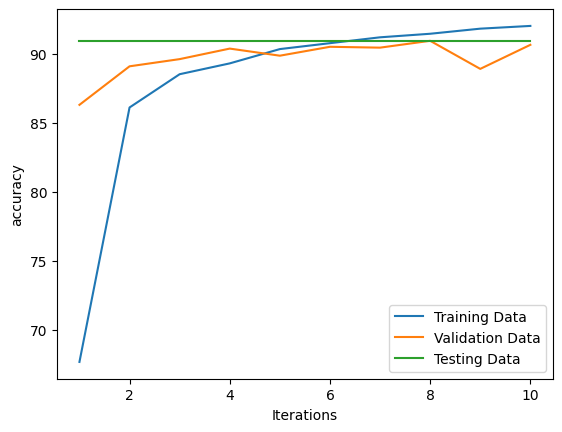

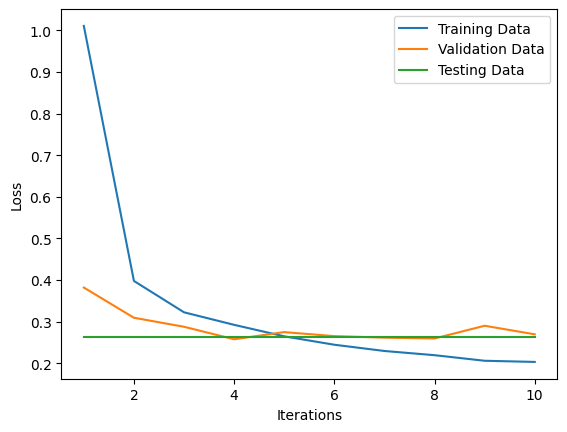

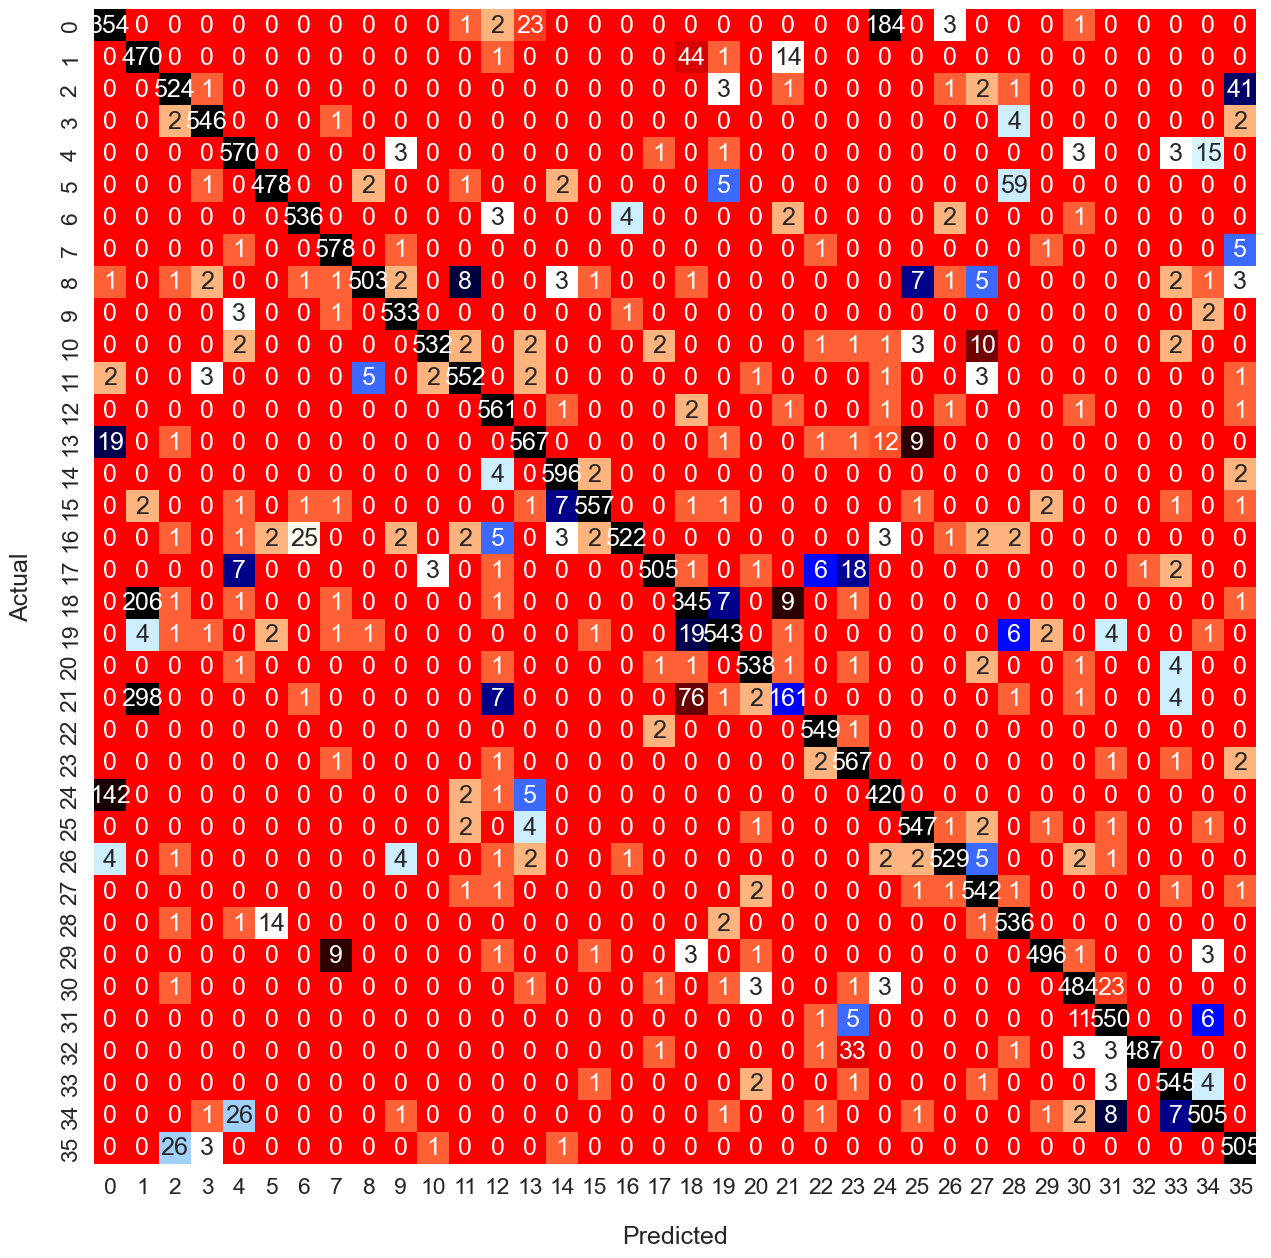

Loss value of model on Testing Data : 0.26252979040145874
Accuracy of model on Testing Data : 90.9375
Classification Reports
              precision    recall  f1-score   support

           0       0.68      0.62      0.65       568
           1       0.48      0.89      0.62       530
           2       0.94      0.91      0.92       574
           3       0.98      0.98      0.98       555
           4       0.93      0.96      0.94       596
           5       0.96      0.87      0.92       548
           6       0.95      0.98      0.96       548
           7       0.97      0.98      0.98       587
           8       0.98      0.93      0.95       543
           9       0.98      0.99      0.98       540
           A       0.99      0.95      0.97       558
           B       0.97      0.97      0.97       572
           C       0.95      0.99      0.97       569
           D       0.93      0.93      0.93       611
           E       0.97      0.99      0.98       604
          

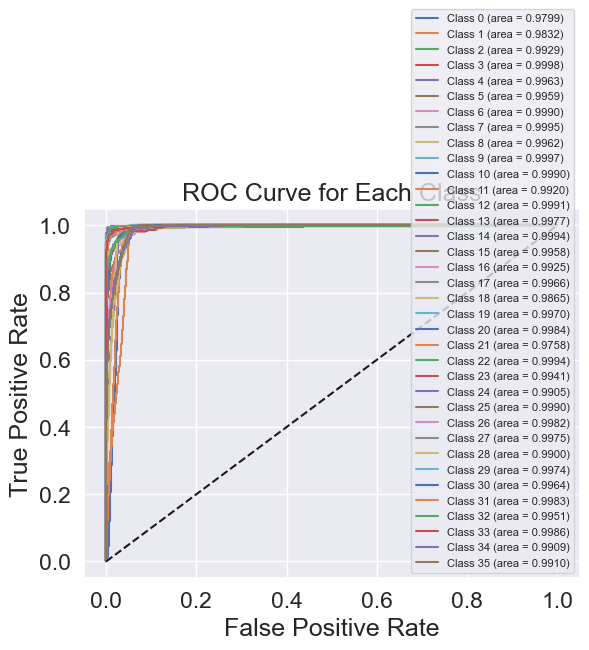

In [13]:
start_time = time.time()
base_model = BaseCNN(0.5).to(device)
train_loss_dic, train_accu_dic, validation_loss_dic, validation_accu_dic, base_weights = train(base_model, train_loader, 0.001, "adam", epochs)
end_time = time.time()
print(f"Training Time : {(end_time - start_time):.2f}")
dic_arr = [train_loss_dic, train_accu_dic, validation_loss_dic, validation_accu_dic]
base_model_accu, base_model_loss = model_test_and_plot(base_model, epochs, dic_arr, test_data)

diff_model_accu["Base"] = base_model_accu
diff_model_loss["Base"] = base_model_loss
diff_model_traning["Base"] = round(end_time - start_time, 3)
diff_model_weights["Base"] = base_weights

In [14]:
print(torchinfo.summary(base_model))

Layer (type:depth-idx)                   Param #
BaseCNN                                  --
├─Conv2d: 1-1                            320
├─Conv2d: 1-2                            18,496
├─Conv2d: 1-3                            73,856
├─Conv2d: 1-4                            295,168
├─Conv2d: 1-5                            295,040
├─Linear: 1-6                            33,024
├─Linear: 1-7                            9,252
├─MaxPool2d: 1-8                         --
├─MaxPool2d: 1-9                         --
├─AvgPool2d: 1-10                        --
├─AvgPool2d: 1-11                        --
├─Tanh: 1-12                             --
├─GELU: 1-13                             --
├─ReLU: 1-14                             --
├─Dropout: 1-15                          --
Total params: 725,156
Trainable params: 725,156
Non-trainable params: 0


# Regularization

# 1. Early Stopping

In [15]:
def early_stopping(model, train_loader, learning_rate, optimizer_type, epochs):

    best_weight = model.state_dict()
    best_accu = 0

    # Variables for early stopping
    patience = 5
    min_delta = 0.01
    patience_counter = 0
    best_loss = float('inf')
    
    criterion = nn.CrossEntropyLoss()
    if optimizer_type == "adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_type == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    elif optimizer_type == "rms":
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)

    train_loss_dic = {}
    train_accu_dic = {}
    validation_loss_dic = {}
    validation_accu_dic = {}

    for epoch in range(epochs):

        train_loss = 0
        total = 0
        correct = 0
        for X, y in train_loader:
            # print("X", X.shape)
            X, y = X.to(device), y.to(device)
            model.train()
            optimizer.zero_grad()
            y_pred = model.forward(X)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            y_pred_val, y_pred_ind = torch.max(y_pred, 1)
            total += y.size(0)
            correct += (y_pred_ind == y).sum().item()
        
        accuracy = 100 * correct / total
        
        print(f'Epoch {epoch+1}\nTraining Loss: {train_loss / len(train_loader)}, Accuracy: {accuracy}')
        train_loss_dic[epoch+1] = train_loss / len(train_loader)
        train_accu_dic[epoch+1] = accuracy
        
        validation_loss = 0
        total = 0
        correct = 0
        for X, y in validate_loader:
            X, y = X.to(device), y.to(device)
            model.eval()
            y_pred = model.forward(X)
            loss = criterion(y_pred, y)
            y_pred_val, y_pred_ind = torch.max(y_pred, 1)
            total += y.size(0)
            correct += (y_pred_ind == y).sum().item()
            validation_loss += loss.item()

        accuracy = 100 * correct / total

        validation_loss_dic[epoch+1] = validation_loss / len(validate_loader)
        validation_accu_dic[epoch+1] = accuracy

        print(f"Validation Loss: {validation_loss_dic[epoch+1]}, Accuracy: {validation_accu_dic[epoch+1]}")

        if validation_accu_dic[epoch+1] > best_accu:
            best_accu = validation_accu_dic[epoch+1]
            best_weight = model.state_dict()

        if round(validation_accu_dic[epoch+1], 1) < round(best_loss, 1) - min_delta:
            best_loss = validation_accu_dic[epoch+1]
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break_epoch = epoch
                break

    return train_loss_dic, train_accu_dic, validation_loss_dic, validation_accu_dic, break_epoch, best_weight

Epoch 1
Training Loss: 0.998205437916257, Accuracy: 68.29117063492063
Validation Loss: 0.3791379394630591, Accuracy: 86.24131944444444
Epoch 2
Training Loss: 0.3915410819906919, Accuracy: 86.34517609126983
Validation Loss: 0.3284438395547488, Accuracy: 88.38045634920636
Epoch 3
Training Loss: 0.3214080212342124, Accuracy: 88.60522073412699
Validation Loss: 0.2843573992214506, Accuracy: 89.36631944444444
Epoch 4
Training Loss: 0.2847675878687629, Accuracy: 89.63758680555556
Validation Loss: 0.26917094616071574, Accuracy: 90.07316468253968
Epoch 5
Training Loss: 0.2608859019228331, Accuracy: 90.37078373015873
Validation Loss: 0.2633904467322051, Accuracy: 90.40798611111111
Epoch 6
Training Loss: 0.24232573160487744, Accuracy: 90.9024677579365
Validation Loss: 0.2745278858476215, Accuracy: 89.94295634920636
Training Time : 72.77
tensor([22, 21, 24,  ..., 34, 12, 19], device='mps:0')
tensor([22,  1, 24,  ..., 34, 12, 19], device='mps:0')


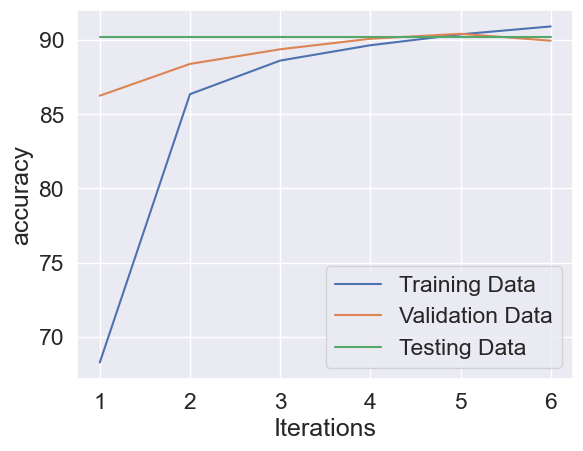

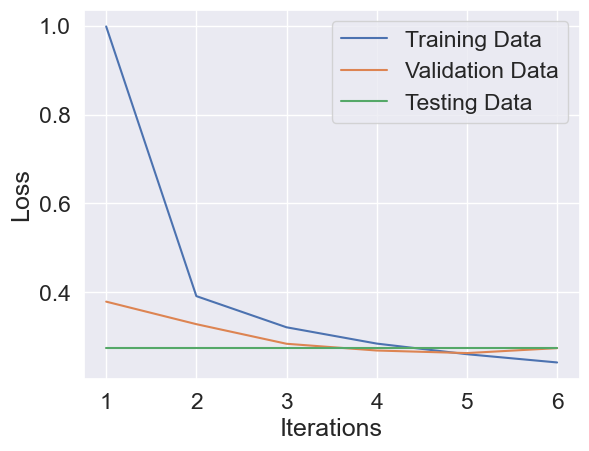

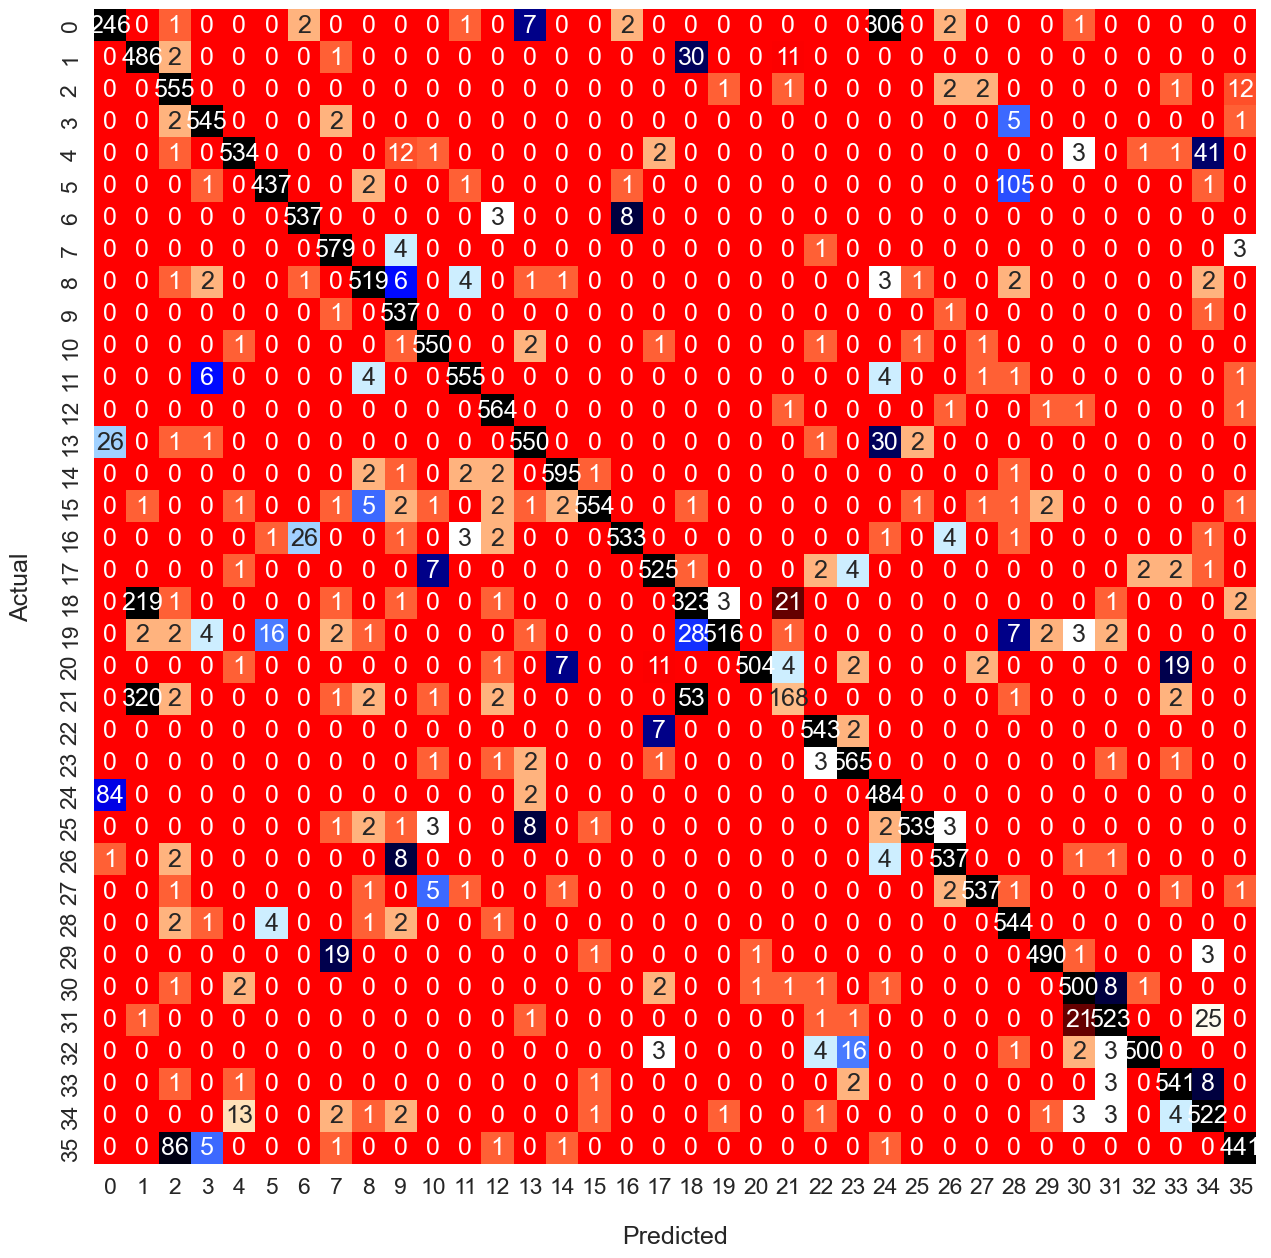

Loss value of model on Testing Data : 0.2757812738418579
Accuracy of model on Testing Data : 90.1686507936508
Classification Reports
              precision    recall  f1-score   support

           0       0.69      0.43      0.53       568
           1       0.47      0.92      0.62       530
           2       0.84      0.97      0.90       574
           3       0.96      0.98      0.97       555
           4       0.96      0.90      0.93       596
           5       0.95      0.80      0.87       548
           6       0.95      0.98      0.96       548
           7       0.95      0.99      0.97       587
           8       0.96      0.96      0.96       543
           9       0.93      0.99      0.96       540
           A       0.97      0.99      0.98       558
           B       0.98      0.97      0.97       572
           C       0.97      0.99      0.98       569
           D       0.96      0.90      0.93       611
           E       0.98      0.99      0.98       604
  

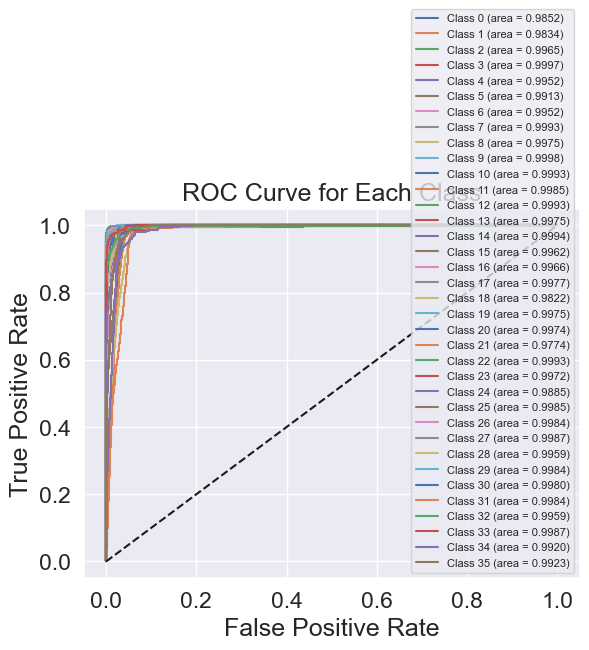

In [16]:
start_time = time.time()
early_stop_model = BaseCNN(0.5).to(device)
train_loss_dic, train_accu_dic, validation_loss_dic, validation_accu_dic, break_epoch, early_stop_weights = early_stopping(early_stop_model, train_loader, 0.001, "adam", epochs)
end_time = time.time()
print(f"Training Time : {(end_time - start_time):.2f}")
dic_arr = [train_loss_dic, train_accu_dic, validation_loss_dic, validation_accu_dic]
early_stop_model_accu, early_stop_model_loss = model_test_and_plot(early_stop_model, break_epoch+1, dic_arr, test_data)

diff_model_accu["Early Stopping"] = early_stop_model_accu
diff_model_loss["Early Stopping"] = early_stop_model_loss
diff_model_traning["Early Stopping"] = round(end_time - start_time, 3)
diff_model_weights["Early Stopping"] = early_stop_weights

# 2. Batch Normalization

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from sklearn.model_selection import train_test_split

class BatchNormCNN(nn.Module):
    def __init__(self, dropout_perc):
        super(BatchNormCNN, self).__init__()
        # CNN layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1) 
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1) 
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.conv5 = nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1)

        self.fc1 = nn.Linear(128 * 1 * 1, 256)
        # self.fc1 = nn.Linear(256 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 36)

        # Pooling layers
        self.max_pool_2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.max_pool_1 = nn.MaxPool2d(kernel_size=2, stride=1, padding=0)
        self.avg_pool_2 = nn.AvgPool2d(kernel_size=2, stride=2, padding=0)
        self.avg_pool_1 = nn.AvgPool2d(kernel_size=2, stride=1, padding=0)

        # Activation functions
        self.tanh = nn.Tanh()
        self.gelu = nn.GELU()
        self.relu = nn.ReLU()

        # Dropout layer
        self.dropout = nn.Dropout(p=dropout_perc)

        # Batch Normalization
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(256)

    def forward(self, x):
        x = self.max_pool_2(self.bn1(self.relu(self.conv1(x))))
        x = self.avg_pool_2(self.gelu(self.conv2(x)))
        x = self.max_pool_2(self.bn2(self.tanh(self.conv3(x))))
        x = self.avg_pool_1(self.bn3(self.gelu(self.conv4(x))))
        x = self.max_pool_1(self.relu(self.conv5(x)))
        x = x.view(-1, 128 * 1 * 1)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Epoch 1
Tranining Loss: 0.6054905567111241, Accuracy: 79.9928695436508
Validation Loss: 0.3114719358938081, Accuracy: 88.72767857142857
Epoch 2
Tranining Loss: 0.32440110830412733, Accuracy: 88.35720486111111
Validation Loss: 0.27444642536815195, Accuracy: 89.74454365079364
Epoch 3
Tranining Loss: 0.28461874842584606, Accuracy: 89.71354166666667
Validation Loss: 0.2554077822123728, Accuracy: 90.40178571428571
Epoch 4
Tranining Loss: 0.26222577004412573, Accuracy: 90.36613343253968
Validation Loss: 0.2553234496819122, Accuracy: 90.30257936507937
Epoch 5
Tranining Loss: 0.24540112929285637, Accuracy: 90.79861111111111
Validation Loss: 0.24547957821143052, Accuracy: 90.19097222222223
Epoch 6
Tranining Loss: 0.23195413684487223, Accuracy: 91.26984126984127
Validation Loss: 0.2508239856374169, Accuracy: 90.38318452380952
Epoch 7
Tranining Loss: 0.21810065160712433, Accuracy: 91.63101438492063
Validation Loss: 0.2593131638058121, Accuracy: 90.56299603174604
Epoch 8
Tranining Loss: 0.20706209

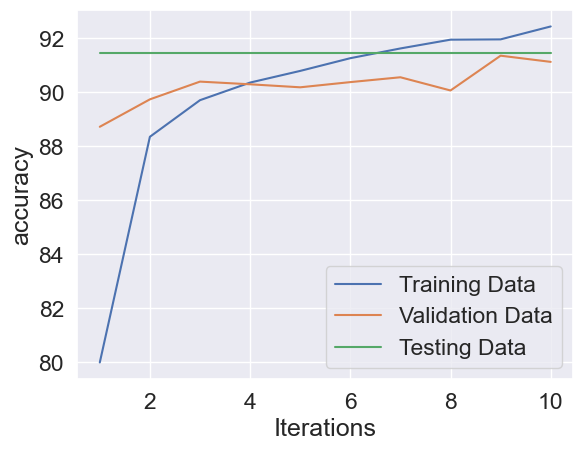

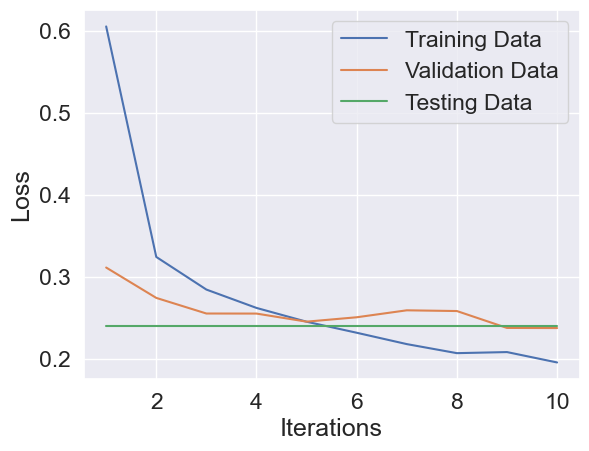

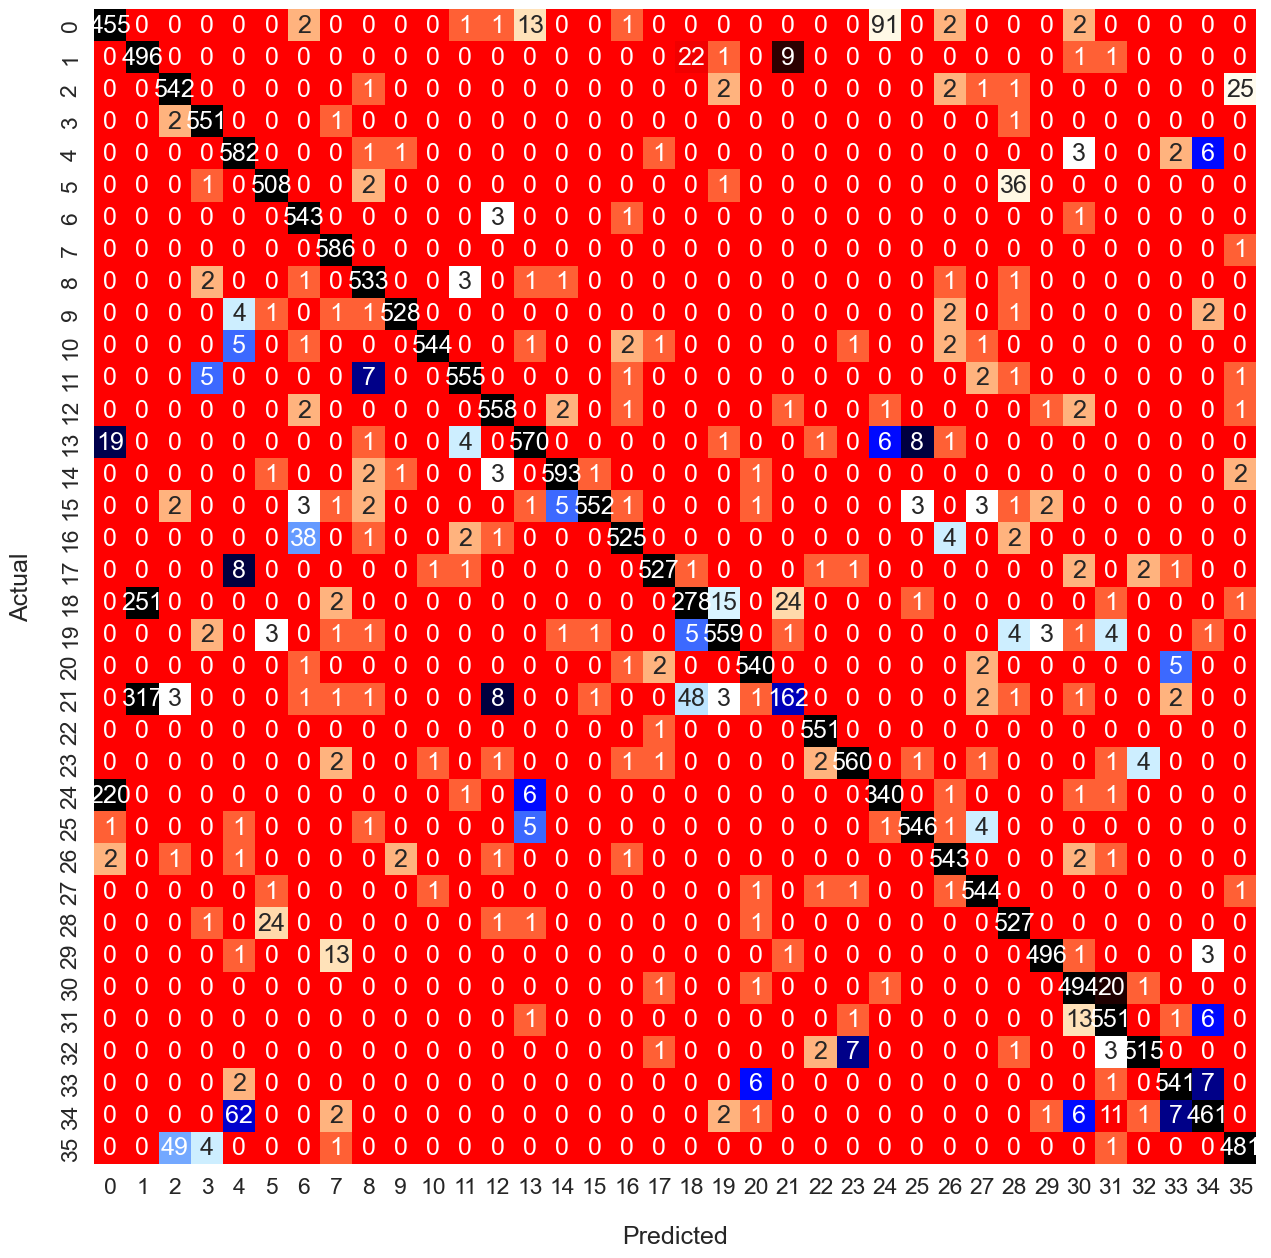

Loss value of model on Testing Data : 0.24060024321079254
Accuracy of model on Testing Data : 91.45337301587301
Classification Reports
              precision    recall  f1-score   support

           0       0.65      0.80      0.72       568
           1       0.47      0.94      0.62       530
           2       0.90      0.94      0.92       574
           3       0.97      0.99      0.98       555
           4       0.87      0.98      0.92       596
           5       0.94      0.93      0.94       548
           6       0.92      0.99      0.95       548
           7       0.96      1.00      0.98       587
           8       0.96      0.98      0.97       543
           9       0.99      0.98      0.99       540
           A       0.99      0.97      0.98       558
           B       0.98      0.97      0.97       572
           C       0.97      0.98      0.97       569
           D       0.95      0.93      0.94       611
           E       0.99      0.98      0.98       604


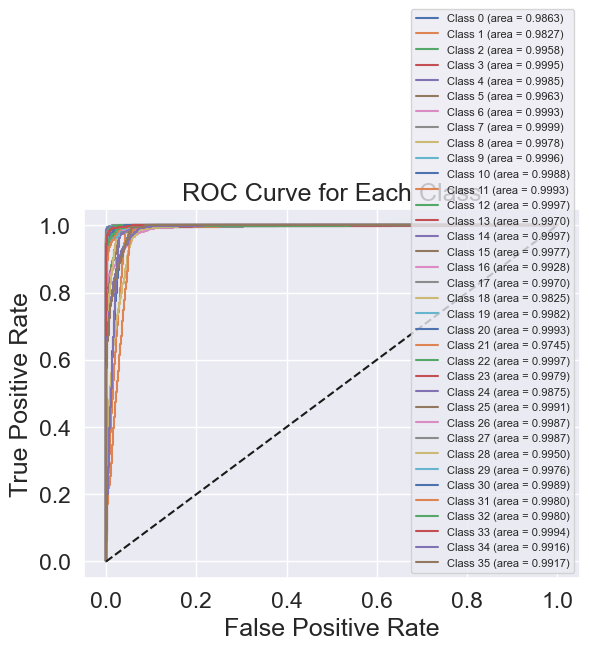

In [18]:
start_time = time.time()
batch_norm_model = BatchNormCNN(0.5).to(device)
train_loss_dic, train_accu_dic, validation_loss_dic, validation_accu_dic, batch_norm_weights = train(batch_norm_model, train_loader, 0.001, "adam", epochs)
end_time = time.time()
print(f"Training Time : {(end_time - start_time):.2f}")
dic_arr = [train_loss_dic, train_accu_dic, validation_loss_dic, validation_accu_dic]
batch_norm_model_accu, batch_norm_model_loss = model_test_and_plot(batch_norm_model, epochs, dic_arr, test_data)

diff_model_accu["Batch Normalization"] = batch_norm_model_accu
diff_model_loss["Batch Normalization"] = batch_norm_model_loss
diff_model_traning["Batch Normalization"] = round(end_time - start_time, 3)
diff_model_weights["Batch Normalization"] = batch_norm_weights

# 3. Learning Rate Schedular

In [19]:
from torch.optim import lr_scheduler

def train_lr_schedular(model, train_loader, learning_rate, optimizer_type, epochs):

    best_weight = model.state_dict()
    best_accu = 0
    
    criterion = nn.CrossEntropyLoss()
    if optimizer_type == "adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_type == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    elif optimizer_type == "rms":
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)

    scheduler = lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.5, total_iters=30)

    train_loss_dic = {}
    train_accu_dic = {}
    validation_loss_dic = {}
    validation_accu_dic = {}

    for epoch in range(epochs):

        train_loss = 0
        total = 0
        correct = 0
        for X, y in train_loader:
            # print("X", X.shape)
            X, y = X.to(device), y.to(device)
            model.train()
            optimizer.zero_grad()
            y_pred = model.forward(X)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            y_pred_val, y_pred_ind = torch.max(y_pred, 1)
            total += y.size(0)
            correct += (y_pred_ind == y).sum().item()
        
        accuracy = 100 * correct / total
        
        print(f'Epoch {epoch+1}\nTraining Loss: {train_loss / len(train_loader)}, Accuracy: {accuracy}')
        train_loss_dic[epoch+1] = train_loss / len(train_loader)
        train_accu_dic[epoch+1] = accuracy
        
        validation_loss = 0
        total = 0
        correct = 0
        for X, y in validate_loader:
            X, y = X.to(device), y.to(device)
            model.eval()
            y_pred = model.forward(X)
            loss = criterion(y_pred, y)
            y_pred_val, y_pred_ind = torch.max(y_pred, 1)
            total += y.size(0)
            correct += (y_pred_ind == y).sum().item()
            validation_loss += loss.item()

        accuracy = 100 * correct / total

        validation_loss_dic[epoch+1] = validation_loss / len(validate_loader)
        validation_accu_dic[epoch+1] = accuracy

        print(f"Validation Loss: {validation_loss_dic[epoch+1]}, Accuracy: {validation_accu_dic[epoch+1]}")


        print(f"LR Before step : {optimizer.param_groups[0]['lr']}")
        scheduler.step()
        print(f"LR After step : {optimizer.param_groups[0]['lr']}")

        if validation_accu_dic[epoch+1] > best_accu:
            best_accu = validation_accu_dic[epoch+1]
            best_weight = model.state_dict()

    return train_loss_dic, train_accu_dic, validation_loss_dic, validation_accu_dic, best_weight

Epoch 1
Training Loss: 0.9568766283226156, Accuracy: 69.2258804563492
Validation Loss: 0.37031536776986385, Accuracy: 86.32192460317461
LR Before step : 0.001
LR After step : 0.0009833333333333332
Epoch 2
Training Loss: 0.38861521234410623, Accuracy: 86.52498759920636
Validation Loss: 0.29142562716844533, Accuracy: 89.31051587301587
LR Before step : 0.0009833333333333332
LR After step : 0.0009666666666666666
Epoch 3
Training Loss: 0.3190456986175998, Accuracy: 88.75248015873017
Validation Loss: 0.28376643132004475, Accuracy: 89.54613095238095
LR Before step : 0.0009666666666666666
LR After step : 0.0009499999999999999
Epoch 4
Training Loss: 0.28668404810337555, Accuracy: 89.58333333333333
Validation Loss: 0.30966115420654655, Accuracy: 88.80208333333333
LR Before step : 0.0009499999999999999
LR After step : 0.0009333333333333332
Epoch 5
Training Loss: 0.2592801378655528, Accuracy: 90.38008432539682
Validation Loss: 0.2676648326247694, Accuracy: 89.6577380952381
LR Before step : 0.00093

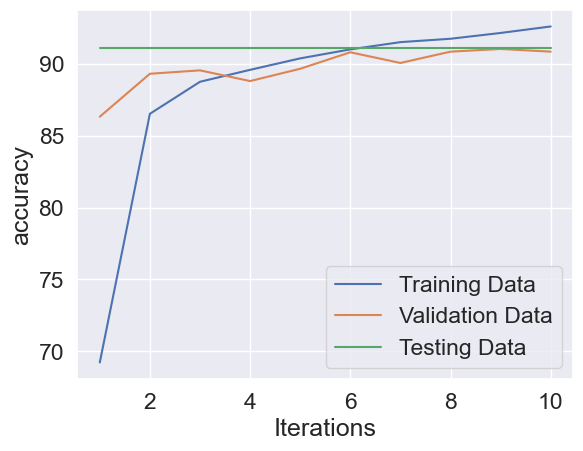

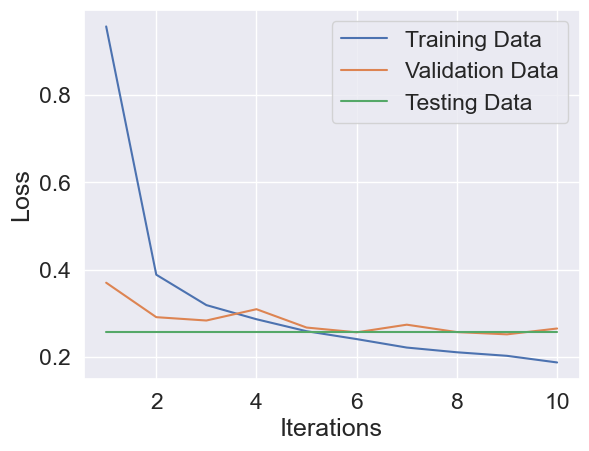

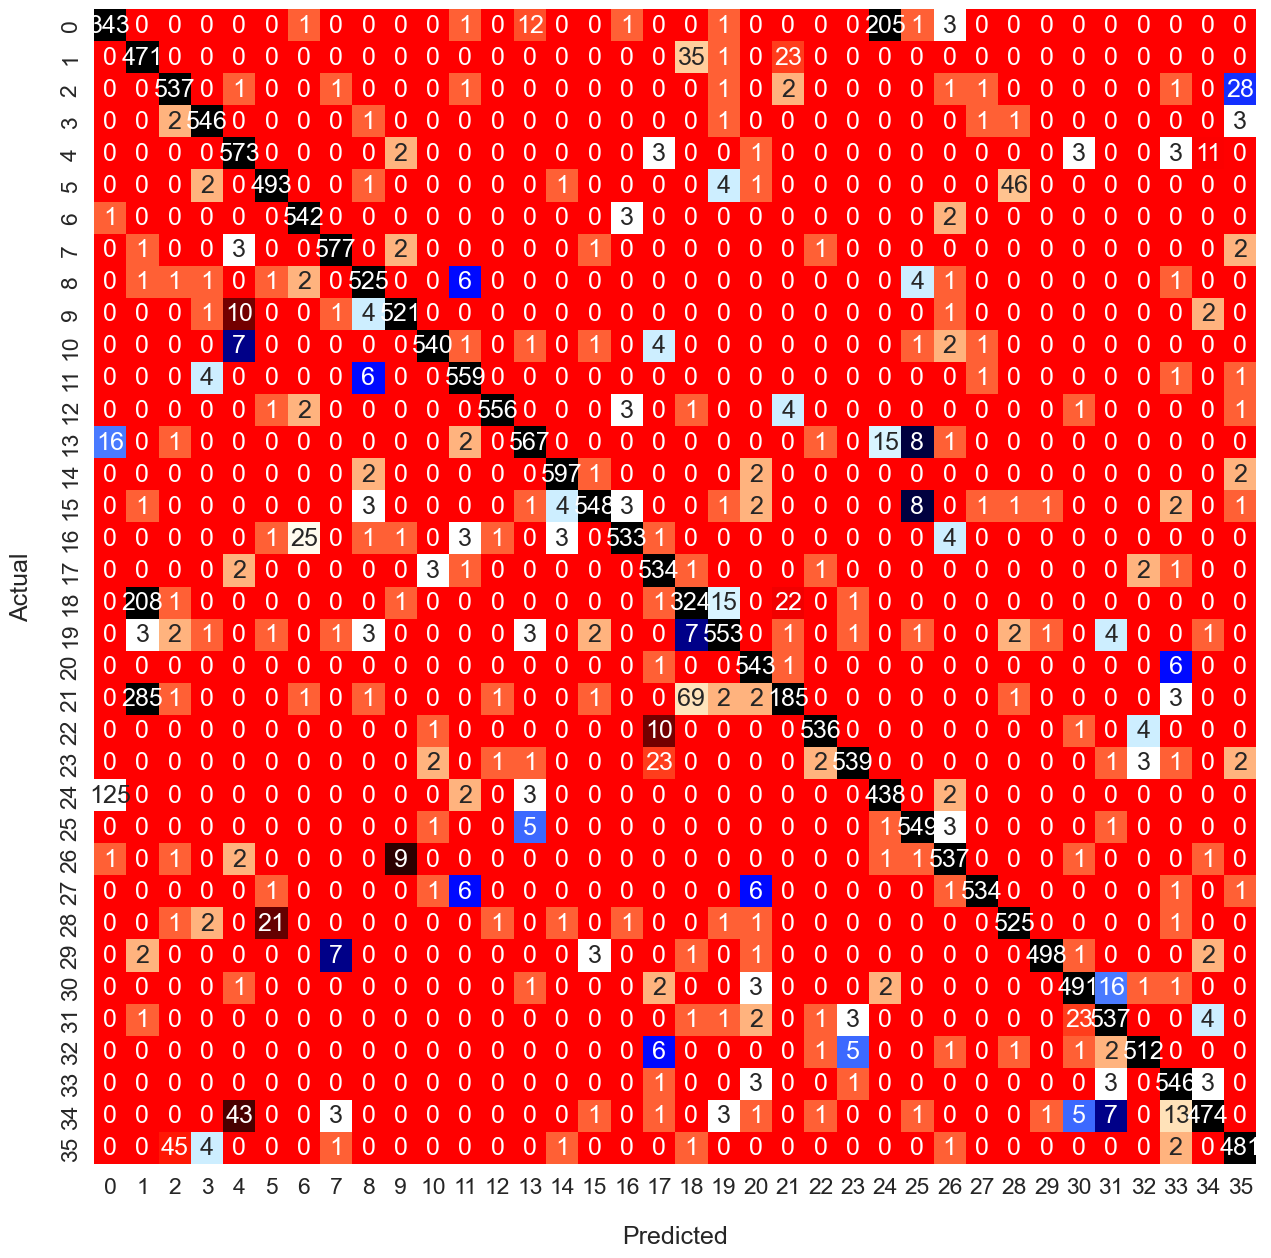

Loss value of model on Testing Data : 0.2579818665981293
Accuracy of model on Testing Data : 91.09126984126983
Classification Reports
              precision    recall  f1-score   support

           0       0.71      0.60      0.65       568
           1       0.48      0.89      0.63       530
           2       0.91      0.94      0.92       574
           3       0.97      0.98      0.98       555
           4       0.89      0.96      0.93       596
           5       0.95      0.90      0.92       548
           6       0.95      0.99      0.97       548
           7       0.98      0.98      0.98       587
           8       0.96      0.97      0.96       543
           9       0.97      0.96      0.97       540
           A       0.99      0.97      0.98       558
           B       0.96      0.98      0.97       572
           C       0.99      0.98      0.98       569
           D       0.95      0.93      0.94       611
           E       0.98      0.99      0.99       604
 

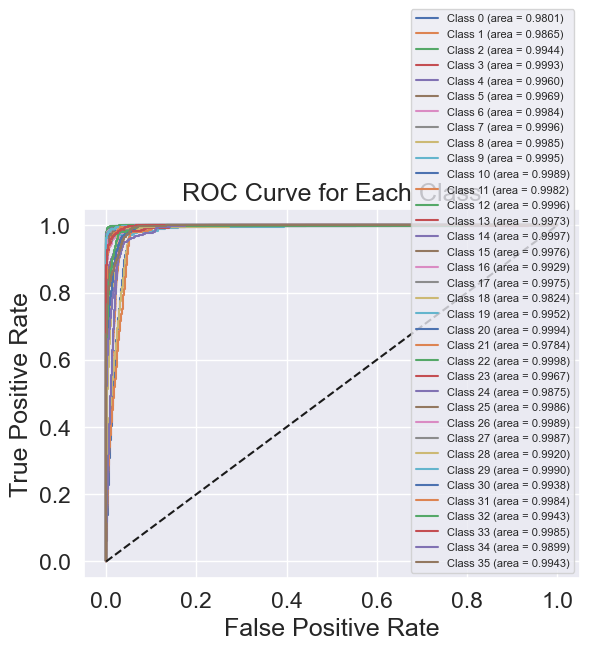

In [20]:
start_time = time.time()
lr_schedular_model = BaseCNN(0.5).to(device)
train_loss_dic, train_accu_dic, validation_loss_dic, validation_accu_dic, lr_scheduler_weights = train_lr_schedular(lr_schedular_model, train_loader, 0.001, "adam", epochs)
end_time = time.time()
print(f"Training Time : {(end_time - start_time):.2f}")
dic_arr = [train_loss_dic, train_accu_dic, validation_loss_dic, validation_accu_dic]
lr_schedular_model_accu, lr_schedular_model_loss = model_test_and_plot(lr_schedular_model, epochs, dic_arr, test_data)

diff_model_accu["LR Schedular"] = lr_schedular_model_accu
diff_model_loss["LR Schedular"] = lr_schedular_model_loss
diff_model_traning["LR Schedular"] = round(end_time - start_time, 3)
diff_model_weights["LR Schedular"] = lr_scheduler_weights

# 4. L2 Regularization

In [21]:
def train_l2_regularization(model, train_loader, learning_rate, optimizer_type, epochs):
    
    best_weight = model.state_dict()
    best_accu = 0
    
    criterion = nn.CrossEntropyLoss()
    if optimizer_type == "adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.0001)
    elif optimizer_type == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=0.0001)
    elif optimizer_type == "rms":
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=0.0001)

    train_loss_dic = {}
    train_accu_dic = {}
    validation_loss_dic = {}
    validation_accu_dic = {}

    for epoch in range(epochs):

        train_loss = 0
        total = 0
        correct = 0
        for X, y in train_loader:
            # print("X", X.shape)
            X, y = X.to(device), y.to(device)
            model.train()
            optimizer.zero_grad()
            y_pred = model.forward(X)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            y_pred_val, y_pred_ind = torch.max(y_pred, 1)
            total += y.size(0)
            correct += (y_pred_ind == y).sum().item()
        
        accuracy = 100 * correct / total
        
        print(f'Epoch {epoch+1}\nTraining Loss: {train_loss / len(train_loader)}, Accuracy: {accuracy}')
        train_loss_dic[epoch+1] = train_loss / len(train_loader)
        train_accu_dic[epoch+1] = accuracy
        
        validation_loss = 0
        total = 0
        correct = 0
        for X, y in validate_loader:
            X, y = X.to(device), y.to(device)
            model.eval()
            y_pred = model.forward(X)
            loss = criterion(y_pred, y)
            y_pred_val, y_pred_ind = torch.max(y_pred, 1)
            total += y.size(0)
            correct += (y_pred_ind == y).sum().item()
            validation_loss += loss.item()

        accuracy = 100 * correct / total

        validation_loss_dic[epoch+1] = validation_loss / len(validate_loader)
        validation_accu_dic[epoch+1] = accuracy

        print(f"Validation Loss: {validation_loss_dic[epoch+1]}, Accuracy: {validation_accu_dic[epoch+1]}")

        if validation_accu_dic[epoch+1] > best_accu:
            best_accu = validation_accu_dic[epoch+1]
            best_weight = model.state_dict()

    return train_loss_dic, train_accu_dic, validation_loss_dic, validation_accu_dic, best_weight

Epoch 1
Training Loss: 0.9946617579442405, Accuracy: 68.11910962301587
Validation Loss: 0.3560036320889753, Accuracy: 87.09077380952381
Epoch 2
Training Loss: 0.402301671596924, Accuracy: 86.01345486111111
Validation Loss: 0.3281188719565906, Accuracy: 88.34945436507937
Epoch 3
Training Loss: 0.3316410535813442, Accuracy: 88.35565476190476
Validation Loss: 0.30390653303927845, Accuracy: 88.88888888888889
Epoch 4
Training Loss: 0.2990054730547681, Accuracy: 89.26401289682539
Validation Loss: 0.3096845057157297, Accuracy: 88.45486111111111
Epoch 5
Training Loss: 0.27497577512755045, Accuracy: 89.98325892857143
Validation Loss: 0.2703430744272376, Accuracy: 90.18477182539682
Epoch 6
Training Loss: 0.2566353692303574, Accuracy: 90.46999007936508
Validation Loss: 0.24979612631871115, Accuracy: 90.87301587301587
Epoch 7
Training Loss: 0.24515524937490385, Accuracy: 90.9055679563492
Validation Loss: 0.2842369182774472, Accuracy: 89.98015873015873
Epoch 8
Training Loss: 0.23428221759460274, Ac

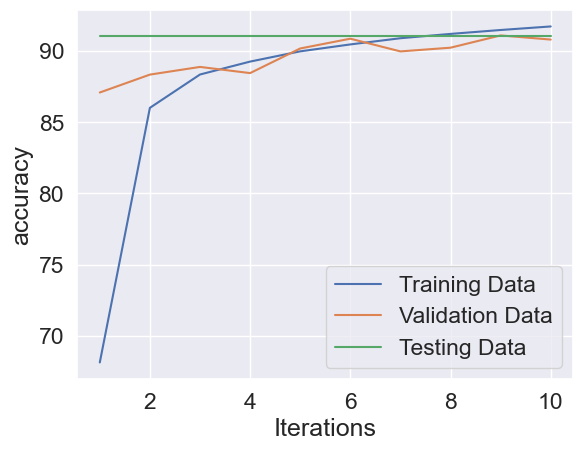

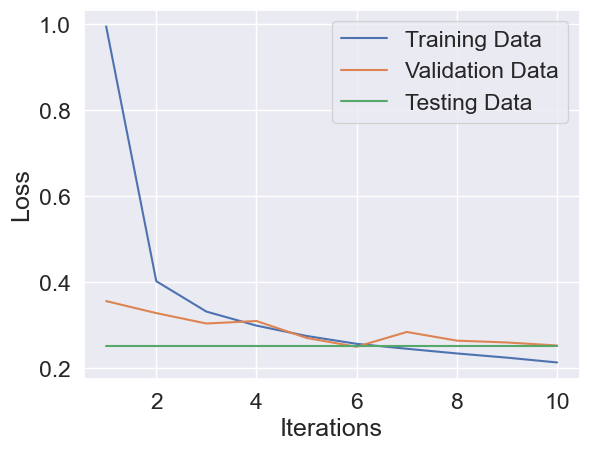

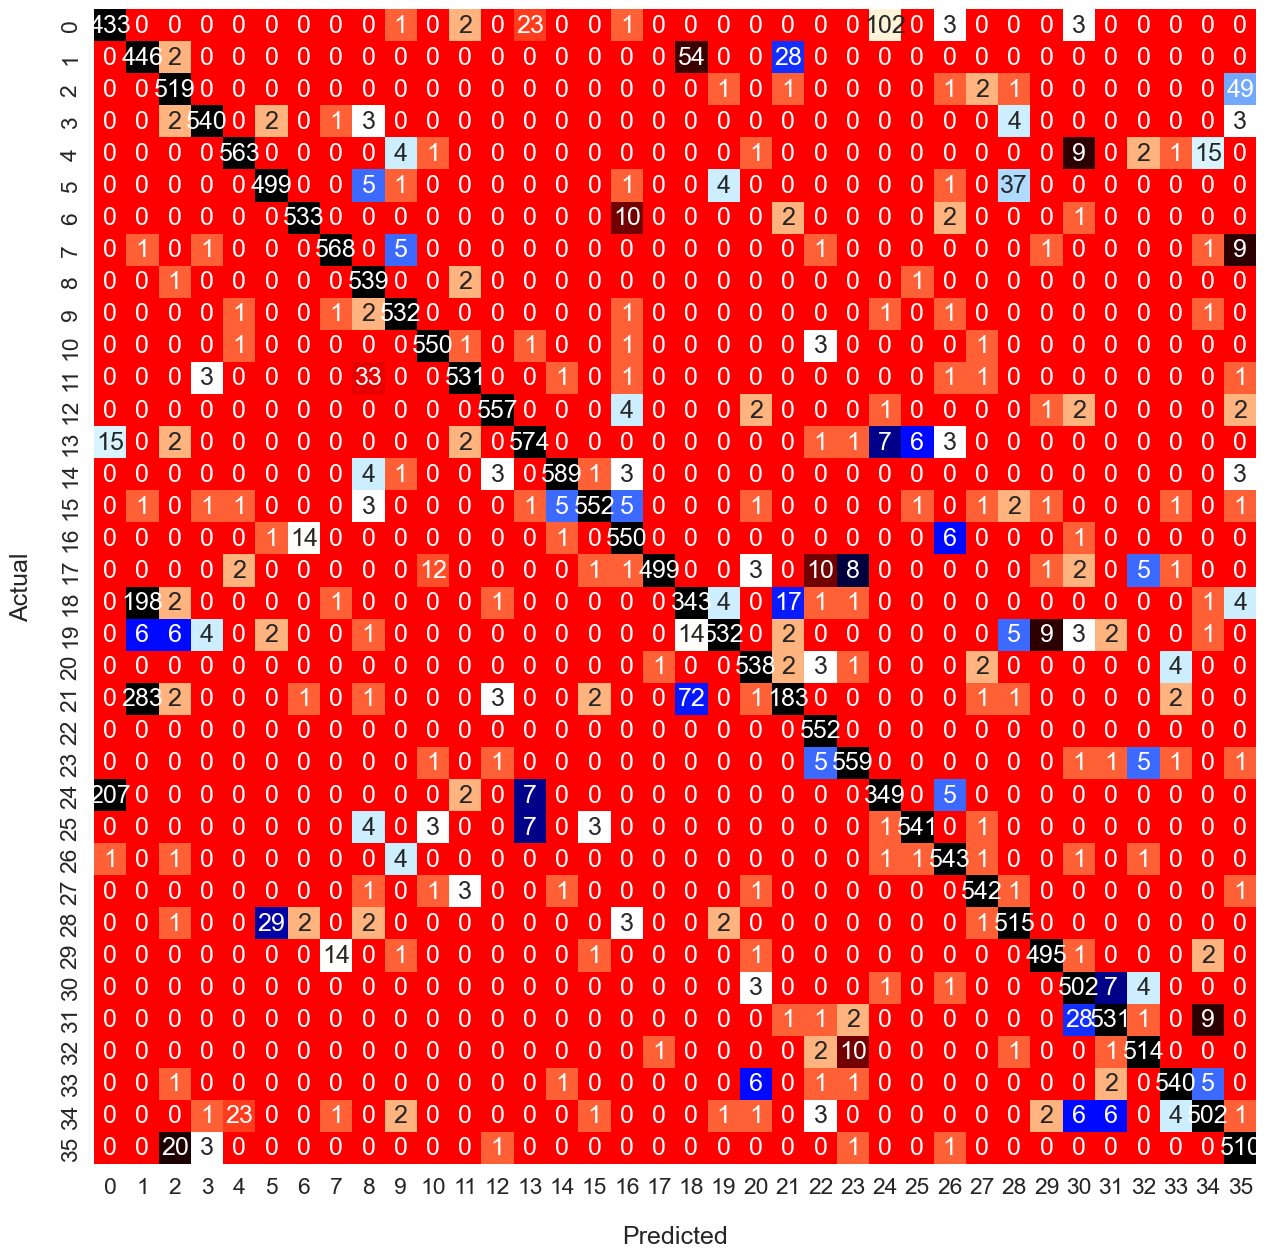

Loss value of model on Testing Data : 0.25253018736839294
Accuracy of model on Testing Data : 91.09623015873017
Classification Reports
              precision    recall  f1-score   support

           0       0.66      0.76      0.71       568
           1       0.48      0.84      0.61       530
           2       0.93      0.90      0.92       574
           3       0.98      0.97      0.97       555
           4       0.95      0.94      0.95       596
           5       0.94      0.91      0.92       548
           6       0.97      0.97      0.97       548
           7       0.97      0.97      0.97       587
           8       0.90      0.99      0.94       543
           9       0.97      0.99      0.98       540
           A       0.97      0.99      0.98       558
           B       0.98      0.93      0.95       572
           C       0.98      0.98      0.98       569
           D       0.94      0.94      0.94       611
           E       0.98      0.98      0.98       604


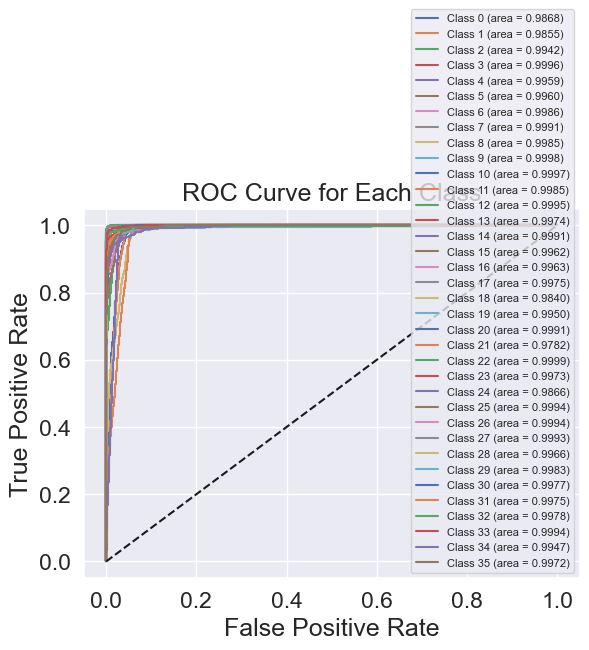

In [22]:
start_time = time.time()
l2_regu_model = BaseCNN(0.5).to(device)
train_loss_dic, train_accu_dic, validation_loss_dic, validation_accu_dic, l2_regu_weights = train_l2_regularization(l2_regu_model, train_loader, 0.001, "adam", epochs)
end_time = time.time()
print(f"Training Time : {(end_time - start_time):.2f}")
dic_arr = [train_loss_dic, train_accu_dic, validation_loss_dic, validation_accu_dic]
l2_regu_model_accu, l2_regu_model_loss = model_test_and_plot(l2_regu_model, epochs, dic_arr, test_data)

diff_model_accu["L2 Regularization"] = l2_regu_model_accu
diff_model_loss["L2 Regularization"] = l2_regu_model_loss
diff_model_traning["L2 Regularization"] = round(end_time - start_time, 2)
diff_model_weights["L2 Regularization"] = l2_regu_weights

In [23]:
print(diff_model_accu)
print(diff_model_loss)
print(diff_model_traning)

{'Base': 90.9375, 'Early Stopping': 90.1686507936508, 'Batch Normalization': 91.45337301587301, 'LR Schedular': 91.09126984126983, 'L2 Regularization': 91.09623015873017}
{'Base': 0.26252979040145874, 'Early Stopping': 0.2757812738418579, 'Batch Normalization': 0.24060024321079254, 'LR Schedular': 0.2579818665981293, 'L2 Regularization': 0.25253018736839294}
{'Base': 185.241, 'Early Stopping': 72.77, 'Batch Normalization': 127.202, 'LR Schedular': 114.14, 'L2 Regularization': 352.15}


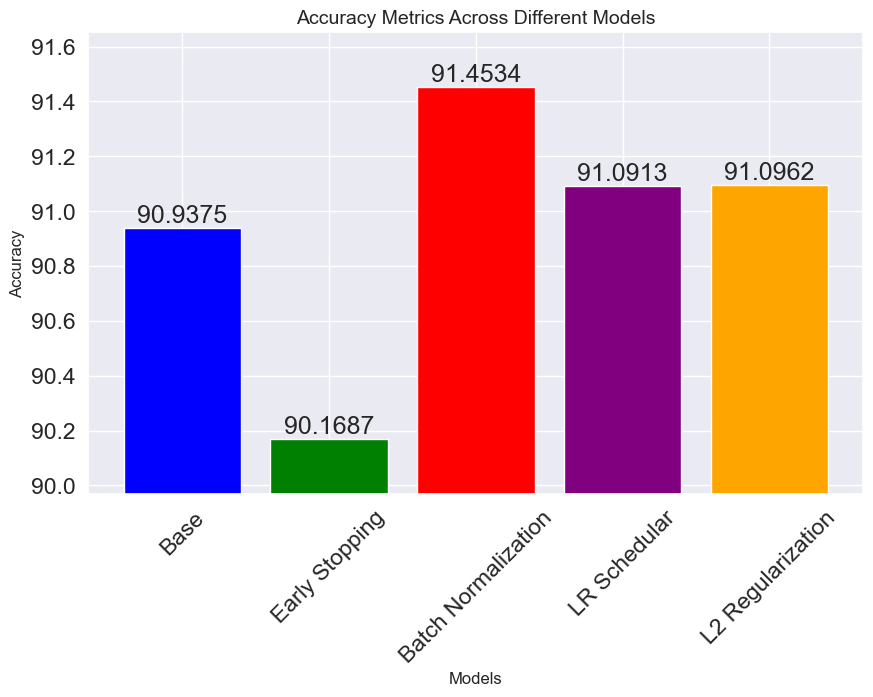

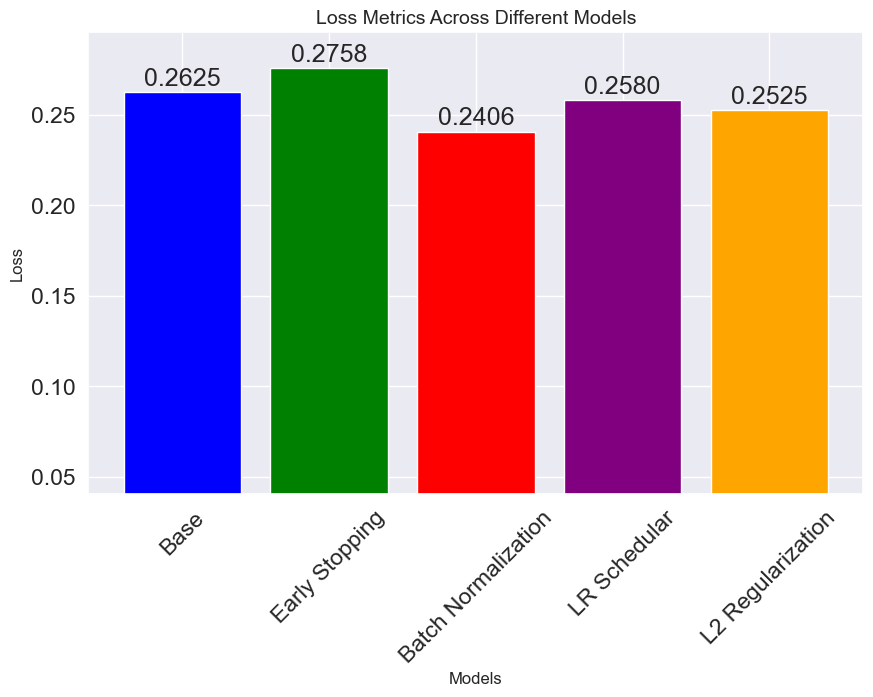

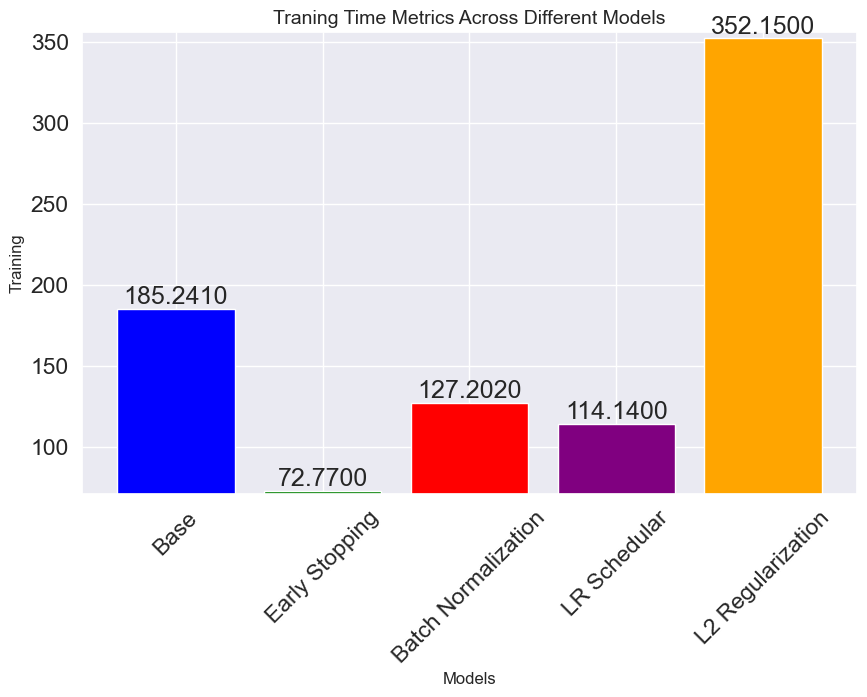

In [24]:
def plot_bar_graph(models, values, plt_title, plt_ylabel, yrange=[0,1]):


    plt.figure(figsize=(10, 6))
    plt.bar(models, values, color=['blue', 'green', 'red', 'purple', 'orange'])

    plt.title(plt_title, fontsize=14)
    plt.xlabel('Models', fontsize=12)
    plt.ylabel(plt_ylabel, fontsize=12)
    plt.xticks(rotation=45)

    for i, acc in enumerate(values):
        plt.text(i, acc + 0.001, f'{acc:.4f}', ha='center', va='bottom')

    plt.ylim(yrange)
    plt.show()

plt_title = 'Accuracy Metrics Across Different Models'
plt_ylabel = 'Accuracy'
yrange = [min(diff_model_accu.values()) - 0.2, max(diff_model_accu.values()) + 0.2]
plot_bar_graph(diff_model_accu.keys(), diff_model_accu.values(), plt_title, plt_ylabel, yrange)

plt_title = 'Loss Metrics Across Different Models'
plt_ylabel = 'Loss'
yrange = [max(min(diff_model_loss.values()) - 0.2, 0), max(diff_model_loss.values()) + 0.02]
plot_bar_graph(diff_model_loss.keys(), diff_model_loss.values(), plt_title, plt_ylabel, yrange)

plt_title = 'Traning Time Metrics Across Different Models'
plt_ylabel = 'Training'
yrange = [min(diff_model_traning.values()) - 2, max(diff_model_traning.values()) + 4]
plot_bar_graph(diff_model_traning.keys(), diff_model_traning.values(), plt_title, plt_ylabel, yrange)



# Saving the best model weights

In [25]:
best_model_name = None
best_model_accu = 0

for model in diff_model_accu:
    if diff_model_accu[model] > best_model_accu:
        best_model_name = model
        best_model_accu = diff_model_accu[model]

if best_model_name == None:
    print("Model does not exist")
else:
    print(f"Best model is {best_model_name}")
    torch.save(diff_model_weights[best_model_name], 'weights/part3_weight.pt')

Best model is Batch Normalization


In [26]:
print(torchinfo.summary(batch_norm_model))

Layer (type:depth-idx)                   Param #
BatchNormCNN                             --
├─Conv2d: 1-1                            320
├─Conv2d: 1-2                            18,496
├─Conv2d: 1-3                            73,856
├─Conv2d: 1-4                            295,168
├─Conv2d: 1-5                            295,040
├─Linear: 1-6                            33,024
├─Linear: 1-7                            9,252
├─MaxPool2d: 1-8                         --
├─MaxPool2d: 1-9                         --
├─AvgPool2d: 1-10                        --
├─AvgPool2d: 1-11                        --
├─Tanh: 1-12                             --
├─GELU: 1-13                             --
├─ReLU: 1-14                             --
├─Dropout: 1-15                          --
├─BatchNorm2d: 1-16                      64
├─BatchNorm2d: 1-17                      256
├─BatchNorm2d: 1-18                      512
Total params: 725,988
Trainable params: 725,988
Non-trainable params: 0


https://www.kaggle.com/code/leifuer/intro-to-pytorch-loading-image-data

https://medium.com/@abhishekjainindore24/pooling-and-their-types-in-cnn-4a4b8a7a4611

https://www.digitalocean.com/community/tutorials/pytorch-torch-max